# **MVNO Customer Churn Analysis**

In [ ]:
# Get the dataset into the google colab
from google.colab import files

In [ ]:
upload_customer = files.upload()

Saving customer_data.json to customer_data.json


In [ ]:
upload_plan = files.upload()

Saving plan_data.json to plan_data.json


In [ ]:
upload_usage = files.upload()

Saving usage_data_500.xlsx to usage_data_500.xlsx


In [ ]:
upload_billing = files.upload()

Saving billing_data_500.xlsx to billing_data_500.xlsx


In [ ]:
# importing the required packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [78]:
# Create Dataframe
df_customer = pd.read_json('customer_data.json')
df_plan = pd.read_json('plan_data.json')
df_billing = pd.read_excel('billing_data_500.xlsx')
df_usage = pd.read_excel('usage_data_500.xlsx')

**Checks the data whether all the datas are properly there or not. If not we'll do the transformation of data to required format**

In [79]:
df_customer.head(10)

,Customer_ID,Age,Region,Join_Date,Status
0,C001,25,Chennai,2024-12-10,Inactive
1,C002,48,Chennai,2025-08-23,Inactive
2,C003,43,Bangalore,2025-04-20,Active
3,C004,25,Bangalore,2024-12-14,Active
4,C005,20,Mumbai,2024-11-01,Active
5,C006,55,Mumbai,2026-01-23,Inactive
6,C007,26,Hyderabad,2025-08-26,Active
7,C008,29,Bangalore,2024-06-19,Inactive
8,C009,50,Bangalore,2024-09-22,Active
9,C010,51,Chennai,2024-09-21,Inactive


In [80]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Customer_ID  50 non-null     object
 1   Age          50 non-null     int64 
 2   Region       50 non-null     object
 3   Join_Date    50 non-null     object
 4   Status       50 non-null     object
dtypes: int64(1), object(4)
memory usage: 2.1+ KB


In [81]:
df_customer['Region'] = df_customer['Region'].astype(np.str_)
df_customer['Join_Date'] = pd.to_datetime(df_customer['Join_Date'])
df_customer['Status'] = df_customer['Status'].astype(np.str_)

In [82]:
df_customer.isnull().sum()

,0
Customer_ID,0
Age,0
Region,0
Join_Date,0
Status,0


In [83]:
df_plan

,Plan_ID,Plan_Name,Plan_Type,Price
0,P001,Basic,Prepaid,199
1,P002,Standard,Prepaid,299
2,P003,Premium,Postpaid,499
3,P004,Unlimited,Postpaid,799


In [84]:
df_usage.head(10)

,Customer_ID,Monthly_Data_Usage_GB,Call_Minutes,SMS_Count
0,C001,47.30,569,52
1,C002,45.43,1472,159
2,C003,26.47,1494,146
3,C004,39.54,1035,10
4,C005,18.75,1446,204
5,C006,41.74,937,214
6,C007,32.19,1495,96
7,C008,24.22,927,275
8,C009,48.50,1381,166
9,C010,18.01,1481,35


In [85]:
df_usage.index

RangeIndex(start=0, stop=500, step=1)

In [86]:
df_usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_ID            500 non-null    object 
 1   Monthly_Data_Usage_GB  500 non-null    float64
 2   Call_Minutes           500 non-null    int64  
 3   SMS_Count              500 non-null    int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 15.8+ KB


In [87]:
df_usage.isnull().sum()

,0
Customer_ID,0
Monthly_Data_Usage_GB,0
Call_Minutes,0
SMS_Count,0


In [88]:
df_billing.head(10)

,Customer_ID,Monthly_Charges,Total_Revenue,Payment_Status
0,C001,799,15181,Pending
1,C002,199,2985,Paid
2,C003,199,3781,Pending
3,C004,799,8789,Pending
4,C005,199,3980,Pending
5,C006,299,6578,Pending
6,C007,199,2786,Pending
7,C008,299,4784,Paid
8,C009,799,19176,Pending
9,C010,299,5681,Paid


In [89]:
df_billing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Customer_ID      500 non-null    object
 1   Monthly_Charges  500 non-null    int64 
 2   Total_Revenue    500 non-null    int64 
 3   Payment_Status   500 non-null    object
dtypes: int64(2), object(2)
memory usage: 15.8+ KB


In [90]:
df_usage.isnull().sum()

,0
Customer_ID,0
Monthly_Data_Usage_GB,0
Call_Minutes,0
SMS_Count,0


**Data Modling**

In [91]:
# df_customer -> Dimension Table
# df_plan -> Dimention Table
# df_billing -> Fact Table
# df_usage -> Fact Table

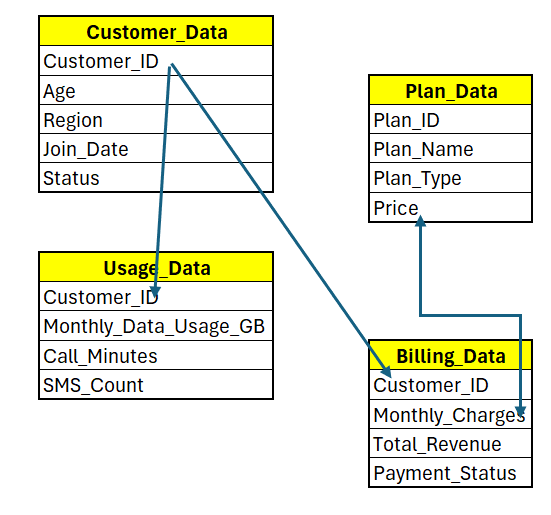

In [92]:
merge_cust_usage = pd.merge(df_customer,df_usage,on='Customer_ID',how='inner')

merge_cust_usage.index

RangeIndex(start=0, stop=50, step=1)

In [93]:
df_billing=df_billing.rename(columns={'Monthly_Charges':'Price'})

In [94]:
merge_plan_billing = pd.merge(df_plan,df_billing,on='Price',how='inner')

merge_plan_billing

,Plan_ID,Plan_Name,Plan_Type,Price,Customer_ID,Total_Revenue,Payment_Status
0,P001,Basic,Prepaid,199,C002,2985,Paid
1,P001,Basic,Prepaid,199,C003,3781,Pending
2,P001,Basic,Prepaid,199,C005,3980,Pending
3,P001,Basic,Prepaid,199,C007,2786,Pending
4,P001,Basic,Prepaid,199,C011,796,Pending
...,...,...,...,...,...,...,...
495,P004,Unlimited,Postpaid,799,C484,19176,Pending
496,P004,Unlimited,Postpaid,799,C487,10387,Paid
497,P004,Unlimited,Postpaid,799,C490,12784,Pending
498,P004,Unlimited,Postpaid,799,C495,3995,Paid


In [95]:
df = pd.merge(merge_cust_usage,merge_plan_billing,on='Customer_ID',how='inner')

df

,Customer_ID,Age,Region,Join_Date,Status,Monthly_Data_Usage_GB,Call_Minutes,SMS_Count,Plan_ID,Plan_Name,Plan_Type,Price,Total_Revenue,Payment_Status
0,C001,25,Chennai,2024-12-10,Inactive,47.30,569,52,P004,Unlimited,Postpaid,799,15181,Pending
1,C002,48,Chennai,2025-08-23,Inactive,45.43,1472,159,P001,Basic,Prepaid,199,2985,Paid
2,C003,43,Bangalore,2025-04-20,Active,26.47,1494,146,P001,Basic,Prepaid,199,3781,Pending
3,C004,25,Bangalore,2024-12-14,Active,39.54,1035,10,P004,Unlimited,Postpaid,799,8789,Pending
4,C005,20,Mumbai,2024-11-01,Active,18.75,1446,204,P001,Basic,Prepaid,199,3980,Pending
5,C006,55,Mumbai,2026-01-23,Inactive,41.74,937,214,P002,Standard,Prepaid,299,6578,Pending
6,C007,26,Hyderabad,2025-08-26,Active,32.19,1495,96,P001,Basic,Prepaid,199,2786,Pending
7,C008,29,Bangalore,2024-06-19,Inactive,24.22,927,275,P002,Standard,Prepaid,299,4784,Paid
8,C009,50,Bangalore,2024-09-22,Active,48.50,1381,166,P004,Unlimited,Postpaid,799,19176,Pending
9,C010,51,Chennai,2024-09-21,Inactive,18.01,1481,35,P002,Standard,Prepaid,299,5681,Paid


In [96]:
df['churn'] = df['Status'].apply(
    lambda x:1 if x=='Inactive' else 0
)

In [97]:
#customer tenure

df['tenure'] = (pd.to_datetime('today')-df['Join_Date']).dt.days

df['tenure']

,tenure
0,544
1,288
2,413
3,540
4,583
5,135
6,285
7,718
8,623
9,624


In [98]:
#ARPU
df['ARPU'] = (df['Total_Revenue']/df['tenure'])

In [99]:
df

,Customer_ID,Age,Region,Join_Date,Status,Monthly_Data_Usage_GB,Call_Minutes,SMS_Count,Plan_ID,Plan_Name,Plan_Type,Price,Total_Revenue,Payment_Status,churn,tenure,ARPU
0,C001,25,Chennai,2024-12-10,Inactive,47.30,569,52,P004,Unlimited,Postpaid,799,15181,Pending,1,544,27.906250
1,C002,48,Chennai,2025-08-23,Inactive,45.43,1472,159,P001,Basic,Prepaid,199,2985,Paid,1,288,10.364583
2,C003,43,Bangalore,2025-04-20,Active,26.47,1494,146,P001,Basic,Prepaid,199,3781,Pending,0,413,9.154964
3,C004,25,Bangalore,2024-12-14,Active,39.54,1035,10,P004,Unlimited,Postpaid,799,8789,Pending,0,540,16.275926
4,C005,20,Mumbai,2024-11-01,Active,18.75,1446,204,P001,Basic,Prepaid,199,3980,Pending,0,583,6.826758
5,C006,55,Mumbai,2026-01-23,Inactive,41.74,937,214,P002,Standard,Prepaid,299,6578,Pending,1,135,48.725926
6,C007,26,Hyderabad,2025-08-26,Active,32.19,1495,96,P001,Basic,Prepaid,199,2786,Pending,0,285,9.775439
7,C008,29,Bangalore,2024-06-19,Inactive,24.22,927,275,P002,Standard,Prepaid,299,4784,Paid,1,718,6.662953
8,C009,50,Bangalore,2024-09-22,Active,48.50,1381,166,P004,Unlimited,Postpaid,799,19176,Pending,0,623,30.780096
9,C010,51,Chennai,2024-09-21,Inactive,18.01,1481,35,P002,Standard,Prepaid,299,5681,Paid,1,624,9.104167


**EDA Operations & Analysis**

In [100]:
df['Customer_ID'].value_counts().sum()

np.int64(50)

In [101]:
df['ARPU'].describe()

,ARPU
count,50.000000
mean,28.806348
std,48.511909
min,1.285945
25%,6.703904
50%,12.053688
75%,23.709892
max,272.829268


In [102]:
# Total Customers
total_customers = df_customer['Customer_ID'].count()
print(f'Total Customers :{total_customers}')

Total Customers :50


In [103]:
# Churn Rate Calculation
# Formula - (Number of Inactive Customers / Total Customers) * 100
inactive_cutomers=df_customer[df_customer['Status']=='Inactive']['Customer_ID'].count()

Churn_Rate = (inactive_cutomers/total_customers)*100

print(f"Churn Rate is {Churn_Rate:.2f}%")

Churn Rate is 44.00%


In [104]:
# Retention Rate calculation
# Formula : (Number of Active Customers/Total Customers) * 100
active_customers = df_customer[df_customer['Status']=='Active']['Customer_ID'].count()

Retention_Rate = (active_customers/total_customers) * 100

print(f'Retention Rate {Retention_Rate:.2f}%')

Retention Rate 56.00%


In [105]:
# ARPU
# Formula : Total Revenue / Number of Users(Subscribers)
total_revenue = df['Total_Revenue'].sum()
print(f'Total Revenue : Rs.{total_revenue:.2f}')

arpu = total_revenue/total_customers
print(f"Average Revenue Per User : Rs.{arpu:.2f}")

Total Revenue : Rs.317258.00
Average Revenue Per User : Rs.6345.16


In [106]:
# Revenue Loss
# Revenue Loss= ∑(Revenue of Churned Customers) : Sum of Revenue (Churned subscriber)

revenue_loss = df[df['Status']=='Inactive']['Total_Revenue'].sum()

print(f'Revenue Loss : Rs.{revenue_loss:.2f}')

Revenue Loss : Rs.155659.00


**Data/Call/SMS Usage Analysis**

In [107]:
# Average Monthly Data Usage (In GB)
avg_monthly_data_usage = df['Monthly_Data_Usage_GB'].mean()

print(f"Average Monthly Data Usage : {avg_monthly_data_usage:.2f} GB")

# Avg Call Minutes

avg_call_minutes = df['Call_Minutes'].mean()

print(f"Average Call Minutes : {avg_call_minutes:.2f} Minutes")

# Avg SMS Count

avg_sms_count = df['SMS_Count'].mean()
print(f"Average SMS Count : {avg_sms_count:.2f}")

Average Monthly Data Usage : 26.55 GB
Average Call Minutes : 876.70 Minutes
Average SMS Count : 148.24


In [108]:
# Plan wise Usage Analysis
plan_wise_usage_analysis = df.groupby('Plan_Name').agg(
    avg_data_usage = ('Monthly_Data_Usage_GB','mean'),
    avg_call_minutes = ('Call_Minutes','mean'),
    avg_sms_count = ('SMS_Count','mean')
)

plan_wise_usage_analysis.columns=['Average Monthly Data Usage','Average Call Minutes','Average SMS Count']

plan_wise_usage_analysis

,Average Monthly Data Usage,Average Call Minutes,Average SMS Count
Plan_Name,,,
Basic,26.237059,920.117647,167.117647
Premium,25.741111,825.777778,125.111111
Standard,29.012727,896.090909,157.272727
Unlimited,25.424615,838.769231,131.923077


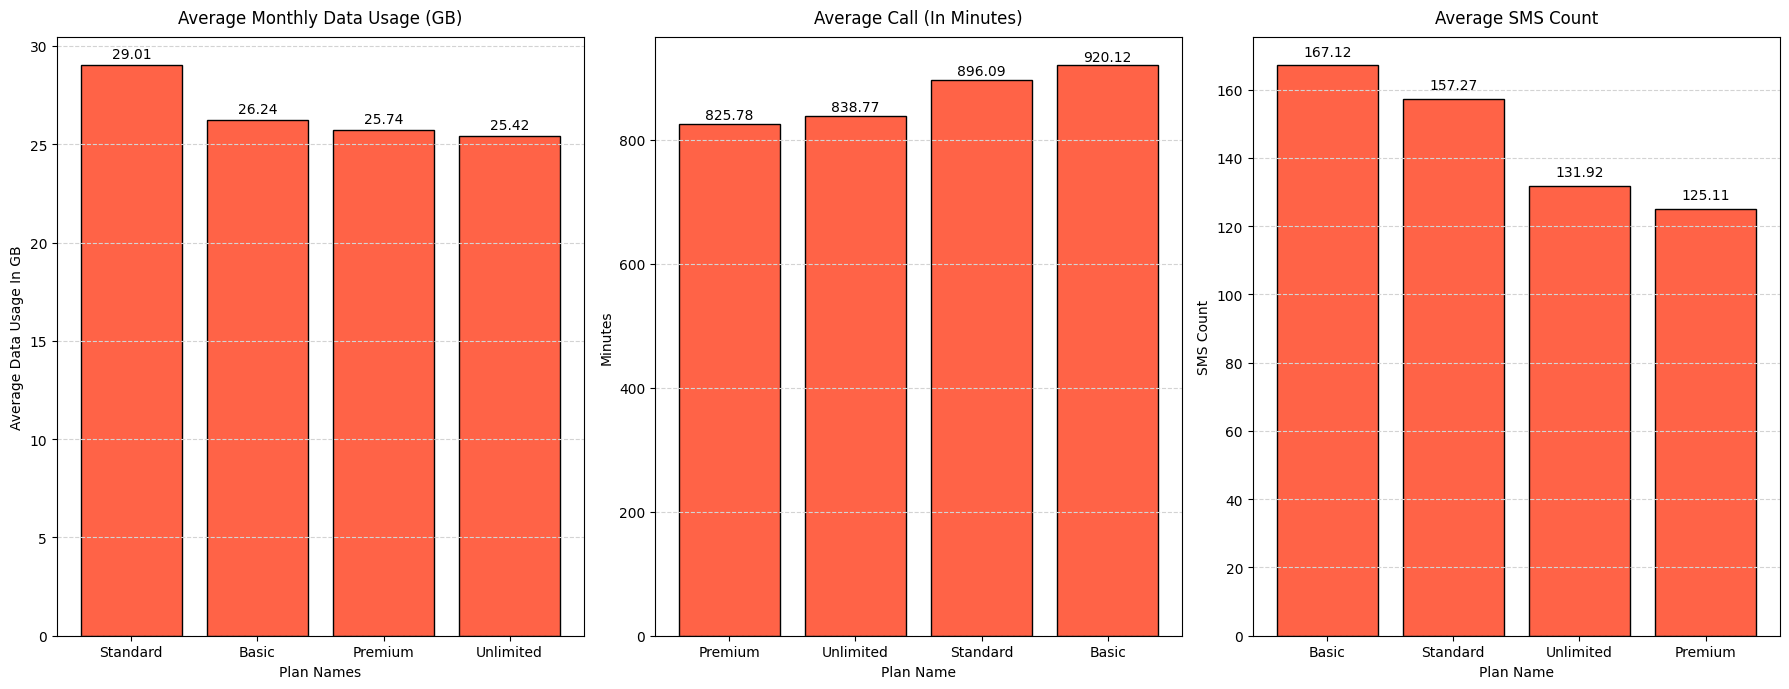

In [109]:
# visualizing the Plan wise usage analysis
import matplotlib.pyplot as plt
plt.figure(figsize=(18,7))


# Average Monthly Data Usage

#Finds the Sorted Data
sorted_data = plan_wise_usage_analysis.sort_values('Average Monthly Data Usage',ascending=False)

plt.subplot(1,3,1)
plt.bar(sorted_data.index,sorted_data['Average Monthly Data Usage'],color='tomato',edgecolor='black')
for x,y in zip(sorted_data.index,sorted_data['Average Monthly Data Usage']):
  plt.text(x,y+0.2,str(f'{y:.2f}'),ha='center',va='bottom')
plt.title('Average Monthly Data Usage (GB)',pad=10)
plt.xlabel('Plan Names')
plt.grid(axis='y',color='lightgray',linestyle='dashed')
plt.ylabel('Average Data Usage In GB')


# Average Call Minutes
sorted_data = plan_wise_usage_analysis.sort_values('Average Call Minutes',ascending=True)
plt.subplot(1,3,2)

plt.bar(sorted_data.index,sorted_data['Average Call Minutes'],color='tomato',edgecolor='black')
for x,y in zip(sorted_data.index,sorted_data['Average Call Minutes']):
  plt.text(x,y+3,str(f'{y:.2f}'),ha='center',va='bottom')
plt.title('Average Call (In Minutes)',pad=10)
plt.xlabel('Plan Name')
plt.ylabel('Minutes')
plt.grid(axis='y',color='lightgray',linestyle='dashed')

# Average SMS Count
sorted_data = plan_wise_usage_analysis.sort_values('Average SMS Count',ascending=False)
plt.subplot(1,3,3)
plt.bar(sorted_data.index,sorted_data['Average SMS Count'],color='tomato',edgecolor='black')
for x,y in zip(sorted_data.index,sorted_data['Average SMS Count']):
  plt.text(x, y+2, f'{y:.2f}', ha='center',va='bottom')
plt.title('Average SMS Count',pad=10)
plt.xlabel('Plan Name')
plt.ylabel('SMS Count')
plt.grid(axis='y',color='lightgray',linestyle='dashed')

plt.tight_layout()
plt.show()

In [110]:
# Plan Type Wise usage analysis
plan_type_wise_usage = df.groupby('Plan_Type').agg(
    Monthly_avg_data_usage = ('Monthly_Data_Usage_GB','mean'),
    avg_call_minutes = ('Call_Minutes','mean'),
    avg_sms_count = ('SMS_Count','mean')
)
plan_type_wise_usage.columns=['Monthly Data Usage (In GB)','Average Call Minutes','Average SMS Count']

plan_type_wise_usage

,Monthly Data Usage (In GB),Average Call Minutes,Average SMS Count
Plan_Type,,,
Postpaid,25.554091,833.454545,129.136364
Prepaid,27.327500,910.678571,163.250000


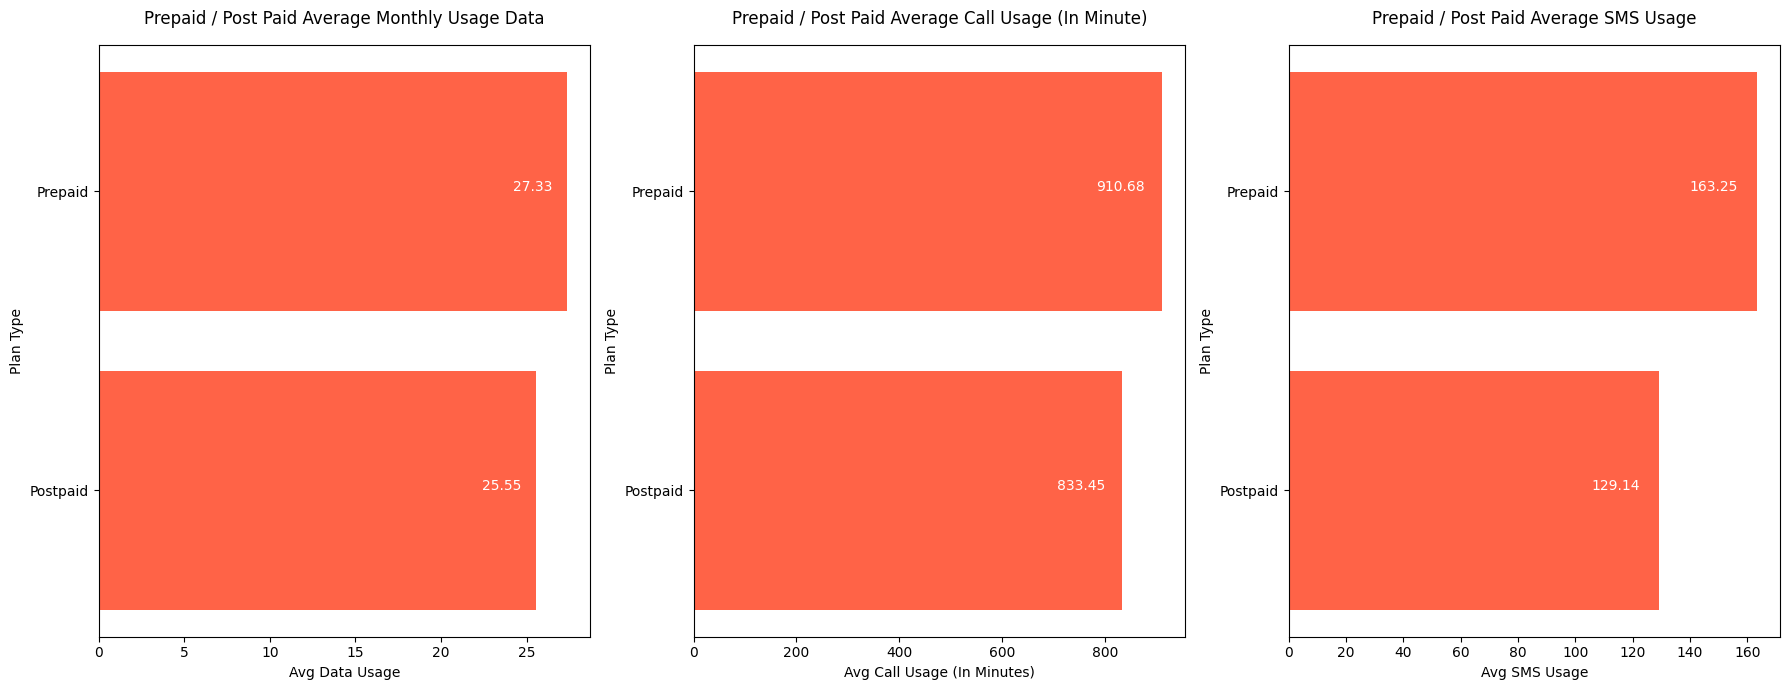

In [111]:
from matplotlib.typing import LineStyleType
# Vsiualization of Plan wise usage analysis
plt.figure(figsize=(18,7))
plt.subplot(1,3,1)

# Avg Monthly Data Usage by Plan Type wise
sorted_data_usage = plan_type_wise_usage.sort_values('Monthly Data Usage (In GB)',ascending=True)
plt.barh(sorted_data_usage.index,sorted_data_usage['Monthly Data Usage (In GB)'],color='tomato')
for x,y in zip(sorted_data_usage.index,sorted_data_usage['Monthly Data Usage (In GB)']):
  plt.text(y-2,x,str(f'{y:.2f}'),ha='center',color='white')
plt.title('Prepaid / Post Paid Average Monthly Usage Data',pad=15)
plt.xlabel('Avg Data Usage')
plt.ylabel('Plan Type')
plt.tight_layout()


plt.subplot(1,3,2)
sorted_call_usage = plan_type_wise_usage.sort_values('Average Call Minutes',ascending=True)
plt.barh(sorted_call_usage.index,sorted_call_usage['Average Call Minutes'],color='tomato')
for x,y in zip(sorted_call_usage.index,sorted_call_usage['Average Call Minutes']):
  plt.text(y-80,x,str(f'{y:.2f}'),ha='center',color='white')
plt.title('Prepaid / Post Paid Average Call Usage (In Minute)',pad=15)
plt.xlabel('Avg Call Usage (In Minutes)')
plt.ylabel('Plan Type')
plt.tight_layout()


plt.subplot(1,3,3)
sorted_sms_usage = plan_type_wise_usage.sort_values('Average SMS Count',ascending=True)
plt.barh(sorted_sms_usage.index,sorted_sms_usage['Average SMS Count'],color='tomato')
for x,y in zip(sorted_sms_usage.index,sorted_sms_usage['Average SMS Count']):
  plt.text(y-15,x,str(f'{y:.2f}'),ha='center',color='white')
plt.title('Prepaid / Post Paid Average SMS Usage',pad=15)
plt.xlabel('Avg SMS Usage')
plt.ylabel('Plan Type')
plt.tight_layout()
plt.show()

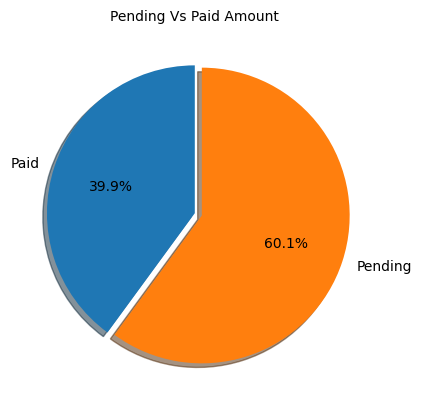

In [112]:
# Paid Vs Pending Payments
pending_vs_paid = df.groupby('Payment_Status').agg(
    Revenue = ('Total_Revenue','sum')
)

plt.pie(pending_vs_paid['Revenue'],labels=pending_vs_paid.index,startangle=90,autopct='%1.1f%%',shadow=True,explode=[0,0.05])
plt.title("Pending Vs Paid Amount",fontsize=10)
plt.show()

In [113]:
df=df.drop(columns=['tenure'])

In [114]:
def age_category(x):
  if x > 40:
    return 'Above 40'
  elif x > 30:
    return 'Above 30'
  else:
    return 'Below 30'
df['age_category'] = df['Age'].apply(age_category)

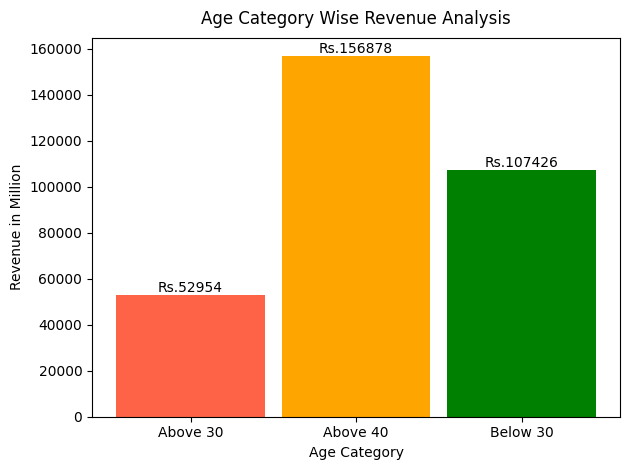

In [115]:
#Age category wise revenue analysis
age_wise_revenue = df.groupby('age_category').agg({
    'Total_Revenue' : 'sum'
})

plt.bar(age_wise_revenue.index,age_wise_revenue['Total_Revenue'],width=0.90,color=['tomato','orange','green'])
for x,y in zip(age_wise_revenue.index,age_wise_revenue['Total_Revenue']):
  plt.text(x,y,f'Rs.{y}',ha='center',va='bottom')

plt.title('Age Category Wise Revenue Analysis',pad=10)
plt.xlabel('Age Category')
plt.ylabel('Revenue in Million')
plt.tight_layout()
plt.show()

**Customer Behavior Analysis**

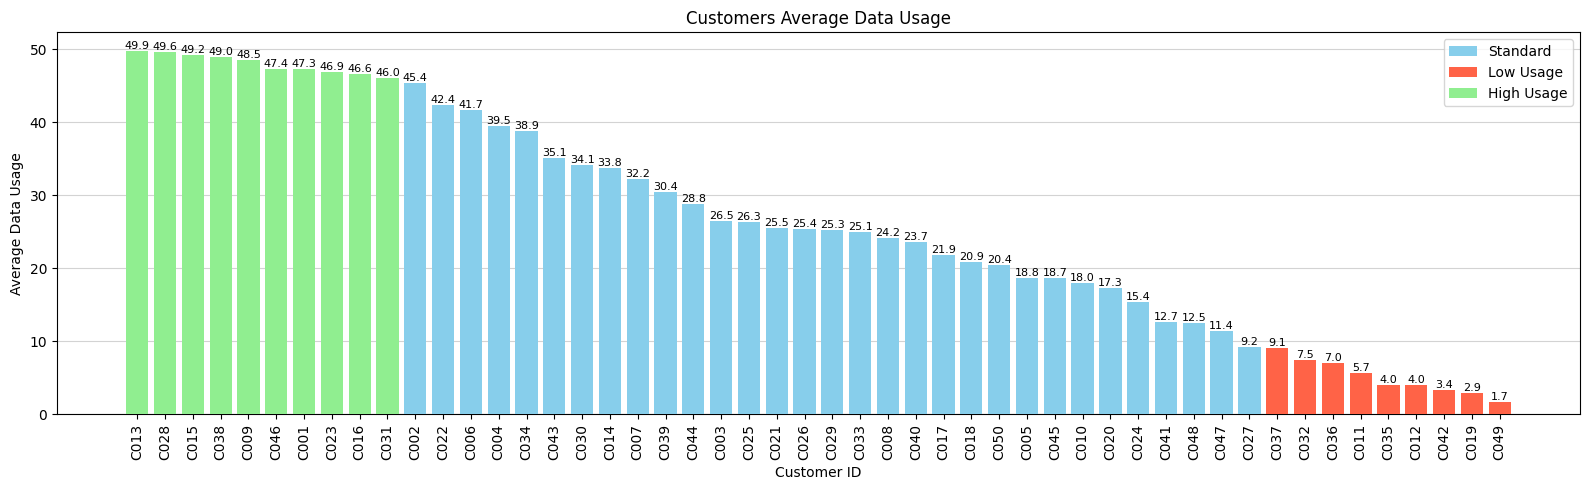

In [116]:
#Avg Data/Call/SMS Usage
from matplotlib.patches import Patch
cust_avg_usage_analysis = df.groupby('Customer_ID').agg(
    Avg_Data_Usage = ('Monthly_Data_Usage_GB','mean'),
    Avg_Call_Usage = ('Call_Minutes','mean'),
    Avg_SMS_Usage = ('SMS_Count','mean')
)

sorted_data_usage = cust_avg_usage_analysis.sort_values('Avg_Data_Usage',ascending=False)
plt.figure(figsize=(16,5))
plt.bar(
    sorted_data_usage.index,
    sorted_data_usage['Avg_Data_Usage'],
    zorder=3,
    color=[
        'lightgreen' if i<10
        else 'tomato' if i>len(sorted_data_usage)-10
        else 'skyblue'
        for i in range(len(sorted_data_usage))
    ]
    )
for x,y in zip(sorted_data_usage.index,sorted_data_usage['Avg_Data_Usage']):
  plt.text(x,y,f'{y:.1f}',ha='center',va='bottom',fontsize=8)

plt.title('Customers Average Data Usage')
plt.xlabel('Customer ID')
plt.ylabel('Average Data Usage')
plt.grid(axis='y',zorder=0,color='lightgray')
plt.xticks(rotation=90)

# Legend Properties
legend_elements = [
    Patch(facecolor='skyblue',label="Standard"),
    Patch(facecolor='tomato',label='Low Usage'),
    Patch(facecolor='lightgreen',label="High Usage")
]

plt.legend(handles=legend_elements)


plt.tight_layout()
plt.show()


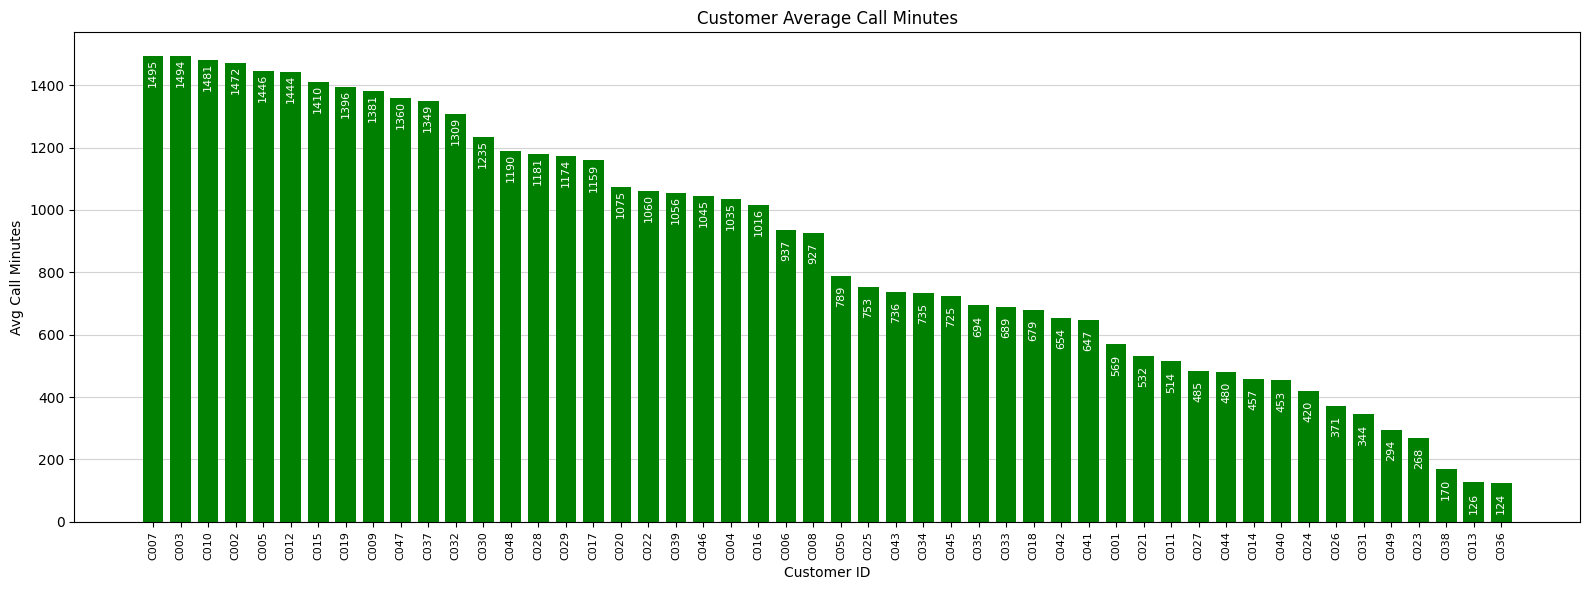

In [117]:
# Customers avg call minutes

sorted_cust_avg_call = cust_avg_usage_analysis.sort_values('Avg_Call_Usage',ascending=False)

plt.figure(figsize=(16,6))
plt.bar(sorted_cust_avg_call.index,sorted_cust_avg_call['Avg_Call_Usage'],width=0.75,zorder=2,color='green')

for x,y in zip(sorted_cust_avg_call.index,sorted_cust_avg_call['Avg_Call_Usage']):
  plt.text(x,y-100,f'{y:.0f}',ha='center',va='bottom',rotation=90,fontsize=8,color='white')

plt.xticks(rotation=90,fontsize=8)
plt.title('Customer Average Call Minutes')
plt.xlabel('Customer ID')
plt.ylabel('Avg Call Minutes')
plt.grid(axis='y',zorder=0,color='lightgray')
plt.tight_layout()
plt.show()

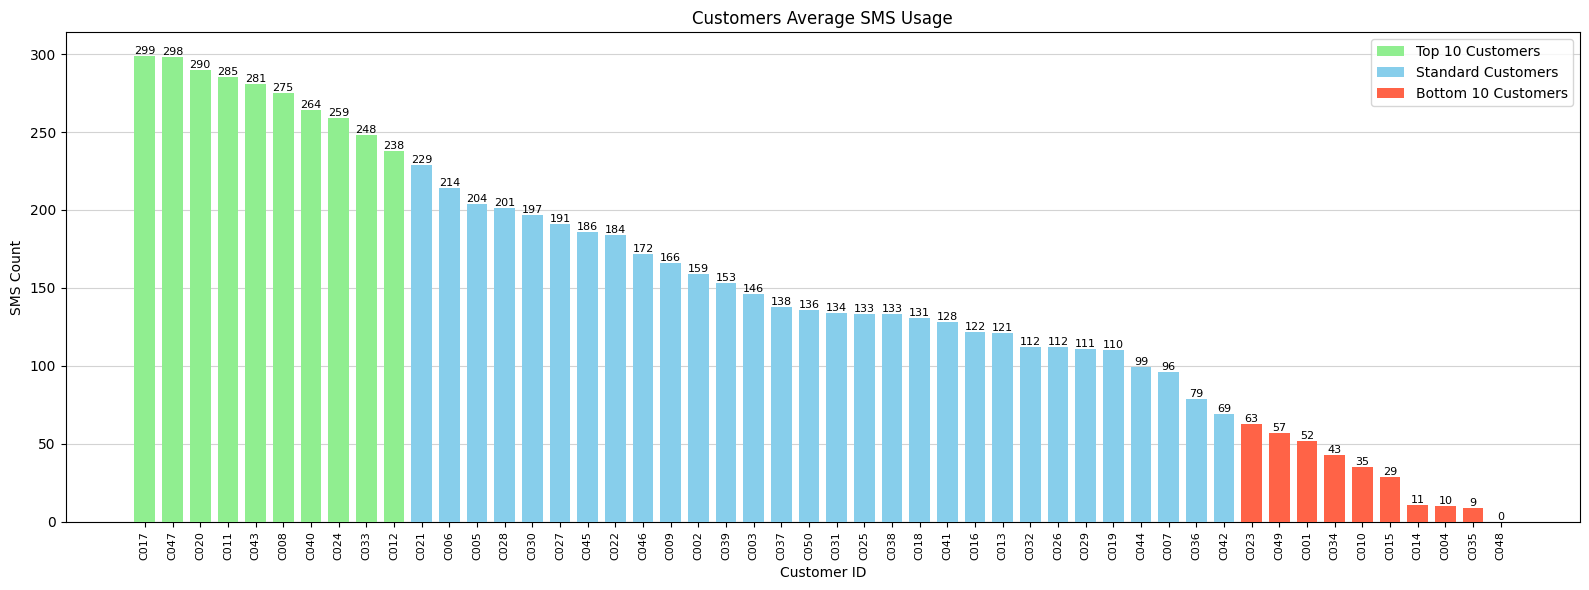

In [146]:
# Customer's Avg SMS Count

from matplotlib.patches import Patch

sorted_avg_sms_count = cust_avg_usage_analysis.sort_values('Avg_SMS_Usage',ascending=False)

plt.figure(figsize=(16,6))

plt.bar(
    sorted_avg_sms_count.index,
    sorted_avg_sms_count['Avg_SMS_Usage'],
    width=0.75,
    zorder=3,
    color=[
        'lightgreen' if i<10
        else 'tomato' if i>=len(sorted_avg_sms_count)-10
        else 'skyblue'
        for i in range(len(sorted_avg_sms_count))
        ])

for x,y in zip(sorted_avg_sms_count.index,sorted_avg_sms_count['Avg_SMS_Usage']):
  plt.text(x,y,f'{y:.0f}',ha='center',va='bottom',fontsize=8)


plt.grid(axis='y',zorder=0,color='lightgray')
plt.title('Customers Average SMS Usage')
plt.xlabel('Customer ID')
plt.ylabel('SMS Count')
plt.xticks(rotation=90,fontsize=8)

legend_elements = [
    Patch(facecolor='lightgreen',label='Top 10 Customers'),
    Patch(facecolor='skyblue',label='Standard Customers'),
    Patch(facecolor='tomato',label='Bottom 10 Customers')
]
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

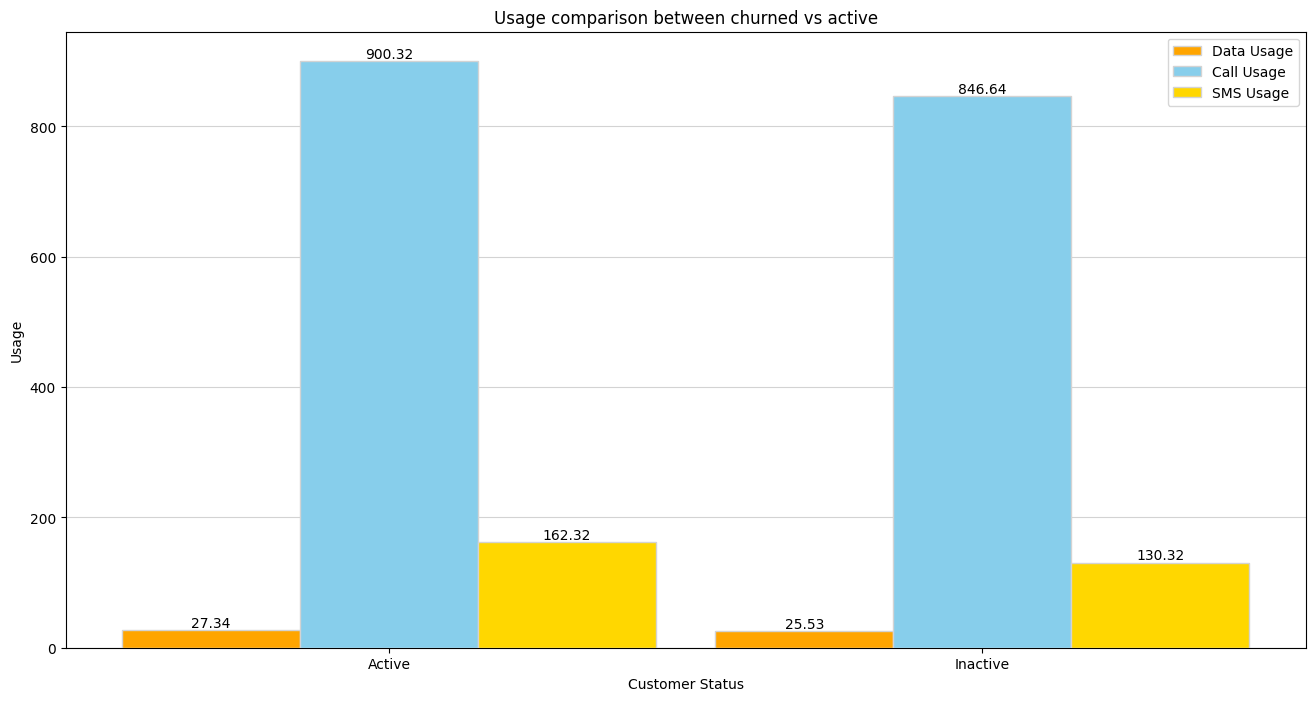

In [119]:
# Usage comparison between churned vs active
active_inactive_cust_usage = df.groupby('Status').agg(
    Data_Usage = ('Monthly_Data_Usage_GB','mean'),
    Call_usage = ('Call_Minutes','mean'),
    SMS_Usage = ('SMS_Count','mean')
)

plt.figure(figsize=(16,8))

cust_type = active_inactive_cust_usage.index

x = np.arange(len(cust_type))
width=0.3

# Bars
data_usage=plt.bar(x-width,active_inactive_cust_usage['Data_Usage'],width=width, color='orange',edgecolor='lightgray',zorder=3,label='Data Usage')
call_usage=plt.bar(x,active_inactive_cust_usage['Call_usage'],width=width,color='skyblue',edgecolor='lightgray',zorder=3,label='Call Usage')
sms_usage=plt.bar(x+width,active_inactive_cust_usage['SMS_Usage'],width=width,color='gold',edgecolor='lightgray',zorder=3,label='SMS Usage')

for bars in [data_usage,call_usage,sms_usage]:
  for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,height,f'{height:.2f}',ha='center',va='bottom')

plt.title('Usage comparison between churned vs active')
plt.xlabel('Customer Status')
plt.ylabel('Usage')
plt.grid(axis='y',color='lightgray',zorder=0)
plt.legend()

plt.xticks(x,cust_type)
plt.show()



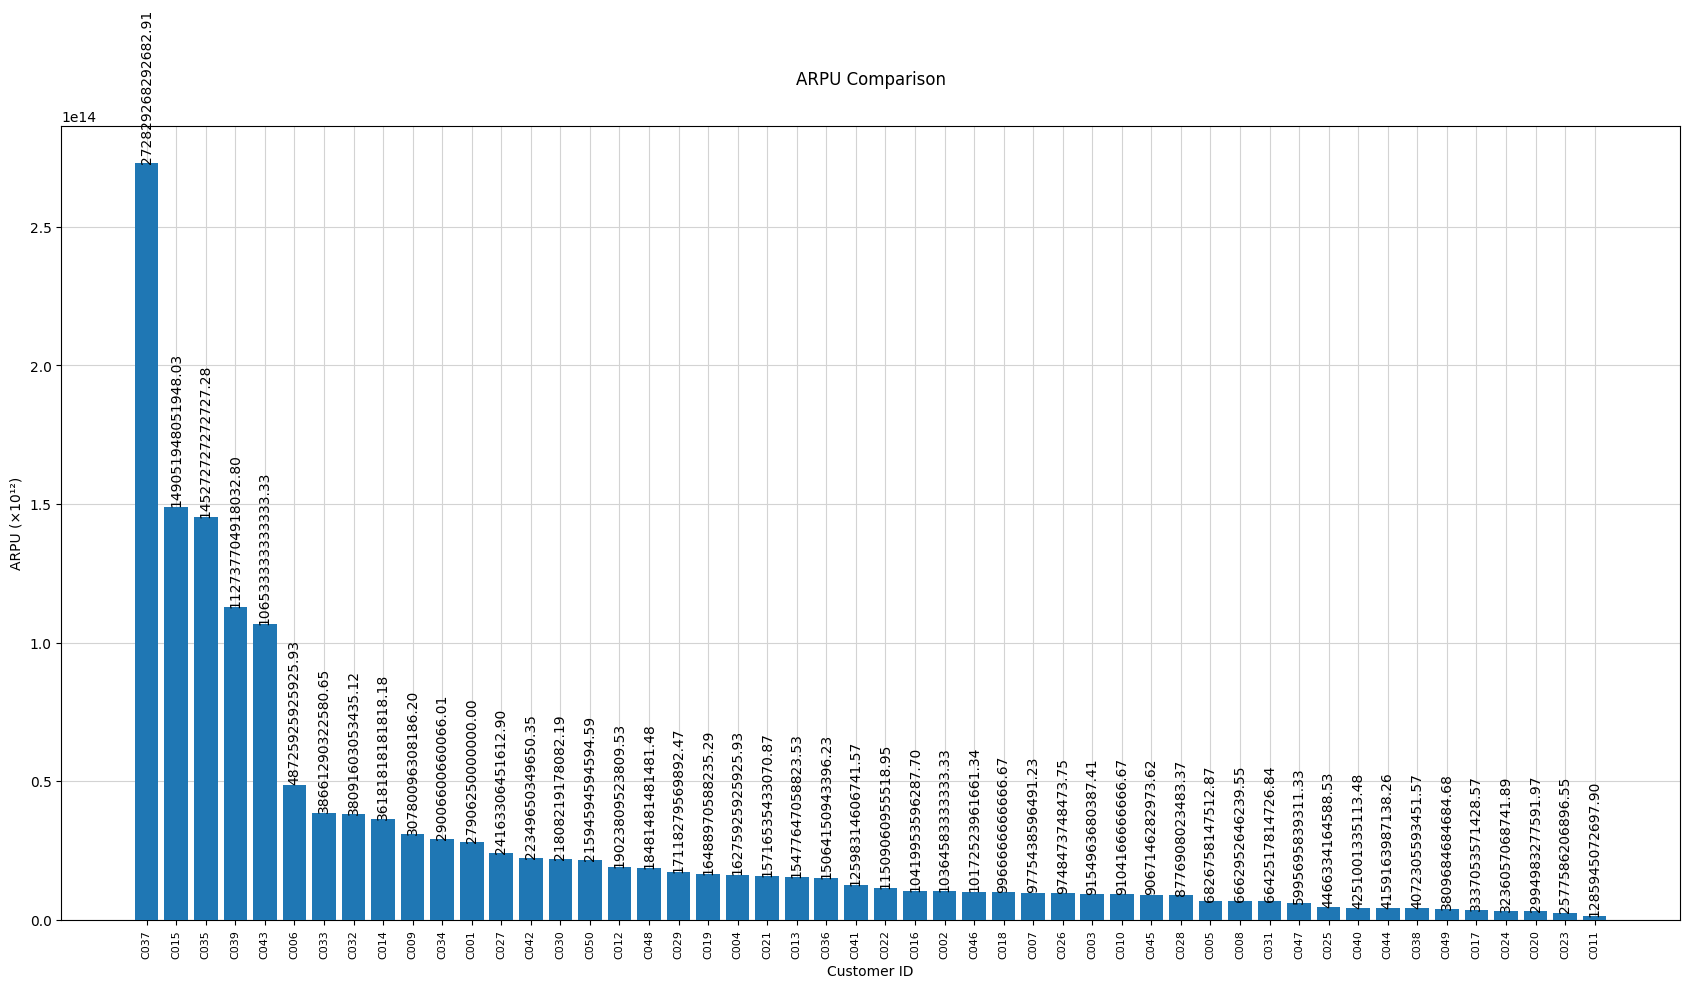

In [120]:
# ARPU Comparision
arpu_comp = df.groupby('Customer_ID').agg(
    ARPU = ('ARPU','mean')
).sort_values('ARPU',ascending=False)

arpu_comp['ARPU'] *= 1e12

plt.figure(figsize=(17,10))
plt.bar(arpu_comp.index,arpu_comp['ARPU'],zorder=3)

for x,y in zip(arpu_comp.index,arpu_comp['ARPU']):
  plt.text(x,y,f'{y:.2f}',ha='center',va='bottom',rotation=90)

plt.xlabel('Customer ID')
plt.ylabel('ARPU (×10¹²)')
plt.title('ARPU Comparison',pad=30)
plt.xticks(fontsize=8,rotation=90)
plt.grid(zorder=0,color='lightgray')
plt.tight_layout()
plt.show()

**Plan Analysis**

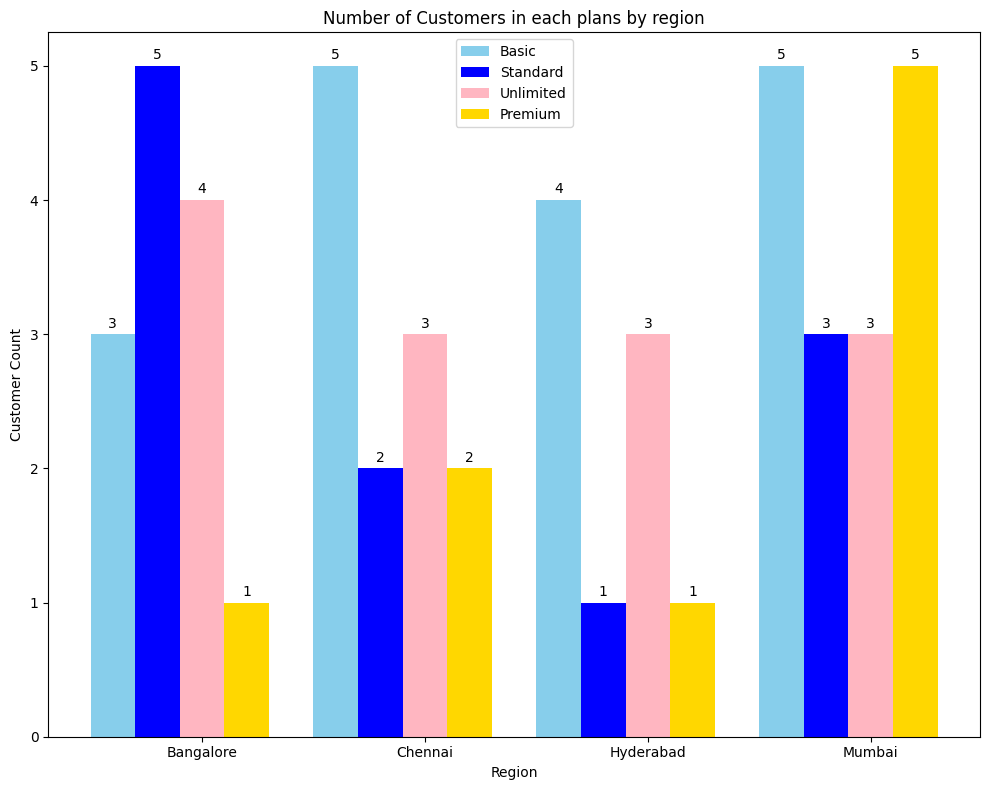

In [121]:
# Number of Customers in each plan by Region

region_wise_plan_count = df.pivot_table(index='Region',columns='Plan_Name',values='Customer_ID',aggfunc='count')

region_wise_plan_count


plans = region_wise_plan_count.index

x = np.arange(len(plans))
width = 0.20

plt.figure(figsize=(10,8))

bar1 = plt.bar(x-0.40,region_wise_plan_count['Basic'],width,label='Basic',color='skyblue')
bar2 = plt.bar(x-width,region_wise_plan_count['Standard'],width,label='Standard',color='blue')
bar3 = plt.bar(x,region_wise_plan_count['Unlimited'],width,label='Unlimited',color='lightpink')
bar4 = plt.bar(x+width,region_wise_plan_count['Premium'],width,label='Premium',color='gold')

for bars in [bar1,bar2,bar3,bar4]:
  for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,height+0.05,height,ha='center')

plt.xticks(x,plans)
plt.title('Number of Customers in each plans by region')
plt.xlabel('Region')
plt.ylabel('Customer Count')
plt.legend()
plt.tight_layout()
plt.show()


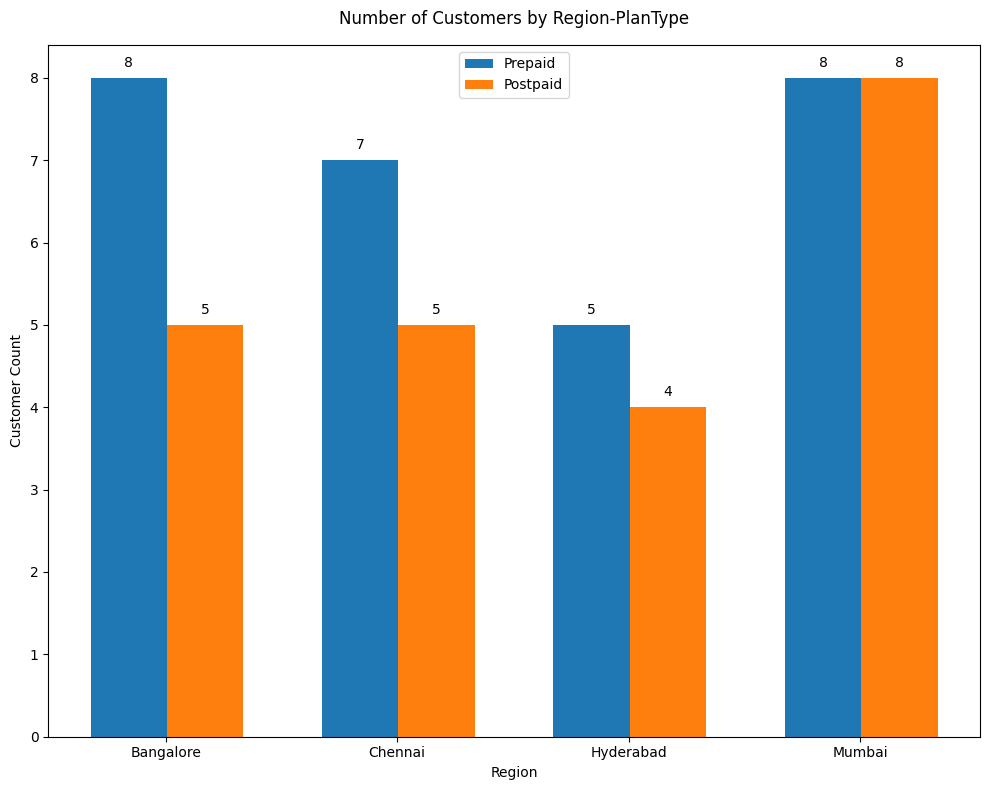

In [122]:
# Number of customers in each plan type(Pre/Post Paid) by region
cust_in_plan_type_by_region = df.pivot_table(index='Region',columns='Plan_Type',values='Customer_ID',aggfunc='count')

Plan_Type = cust_in_plan_type_by_region.index

x = np.arange(len(Plan_Type))
width = 0.33

plt.figure(figsize=(10,8))

prepaid = plt.bar(x-width,cust_in_plan_type_by_region['Prepaid'],width,label='Prepaid')
postpaid = plt.bar(x,cust_in_plan_type_by_region['Postpaid'],width,label='Postpaid')

for bars in [prepaid,postpaid]:
  for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,height+0.1,height,ha='center',va='bottom')

plt.xticks(x-0.17,Plan_Type)
plt.title('Number of Customers by Region-PlanType',pad=15)
plt.xlabel('Region')
plt.ylabel('Customer Count')
plt.legend()
plt.tight_layout()
plt.show()


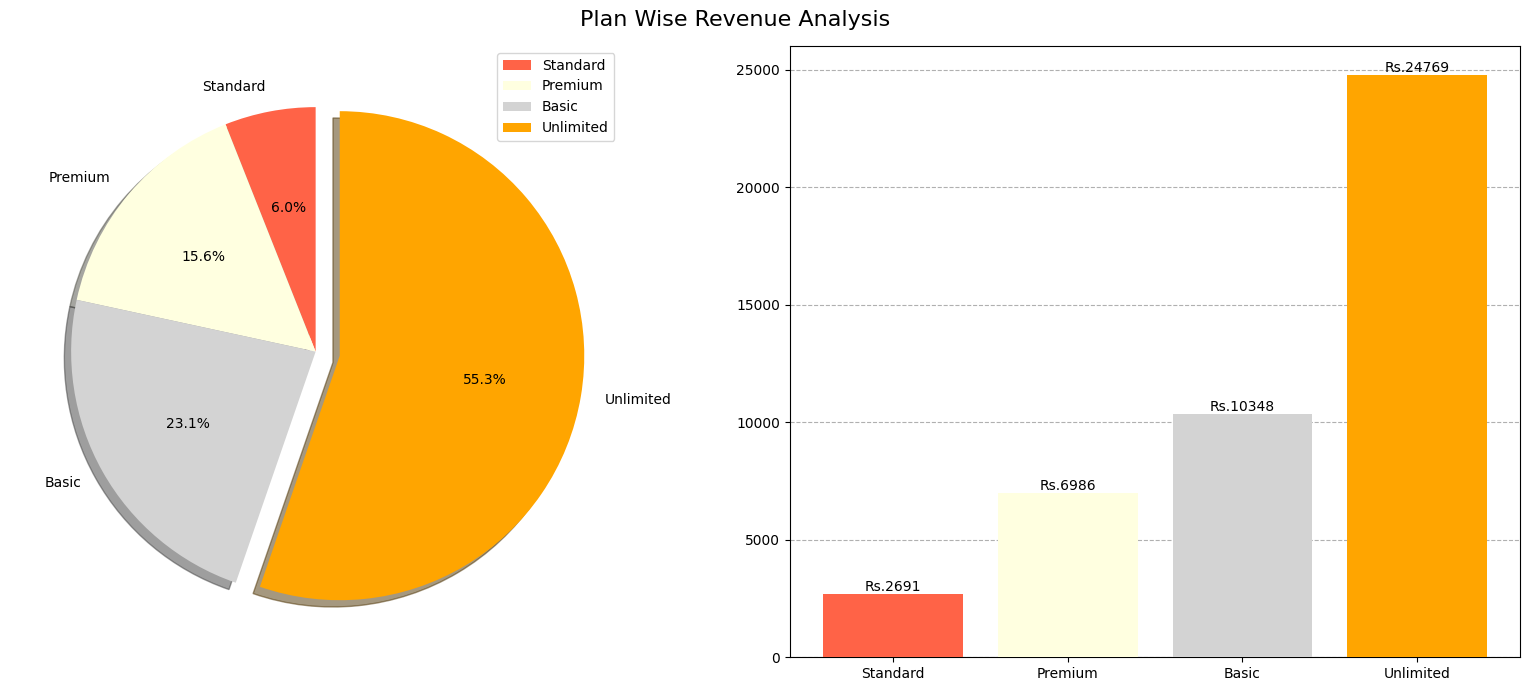

In [148]:
# Plan wise revenue
plan_wise_revenue = df[(df['Payment_Status']=='Paid') & (df['Status']=='Active')].groupby('Plan_Name').agg(
    Revenue = ('Total_Revenue','sum')
).sort_values('Revenue',ascending=True)

plt.figure(figsize=(16,7))
#plt.figtext(1,3,'Revenue By Plan')
plt.subplot(1,2,1)
plt.pie(plan_wise_revenue['Revenue'],labels=plan_wise_revenue.index,colors=['tomato','lightyellow','lightgray','orange'],startangle=90,explode=[0,0,0,0.1],shadow=True,autopct='%1.1f%%')
#plt.title('Plan wise - Revenue Distribution %')
plt.legend()


plt.subplot(1,2,2)
plt.bar(plan_wise_revenue.index,plan_wise_revenue['Revenue'],color=['tomato','lightyellow','lightgray','orange'],zorder=3)
for x,y in zip(plan_wise_revenue.index,plan_wise_revenue['Revenue']):
  plt.text(x,y,f'Rs.{y}',ha='center',va='bottom')

plt.grid(axis='y',linestyle='--',zorder=0)

plt.suptitle('Plan Wise Revenue Analysis',fontsize=16)
#rect = [left, bottom, right, top]
plt.tight_layout(rect=[0,0,1,1])

plt.show()

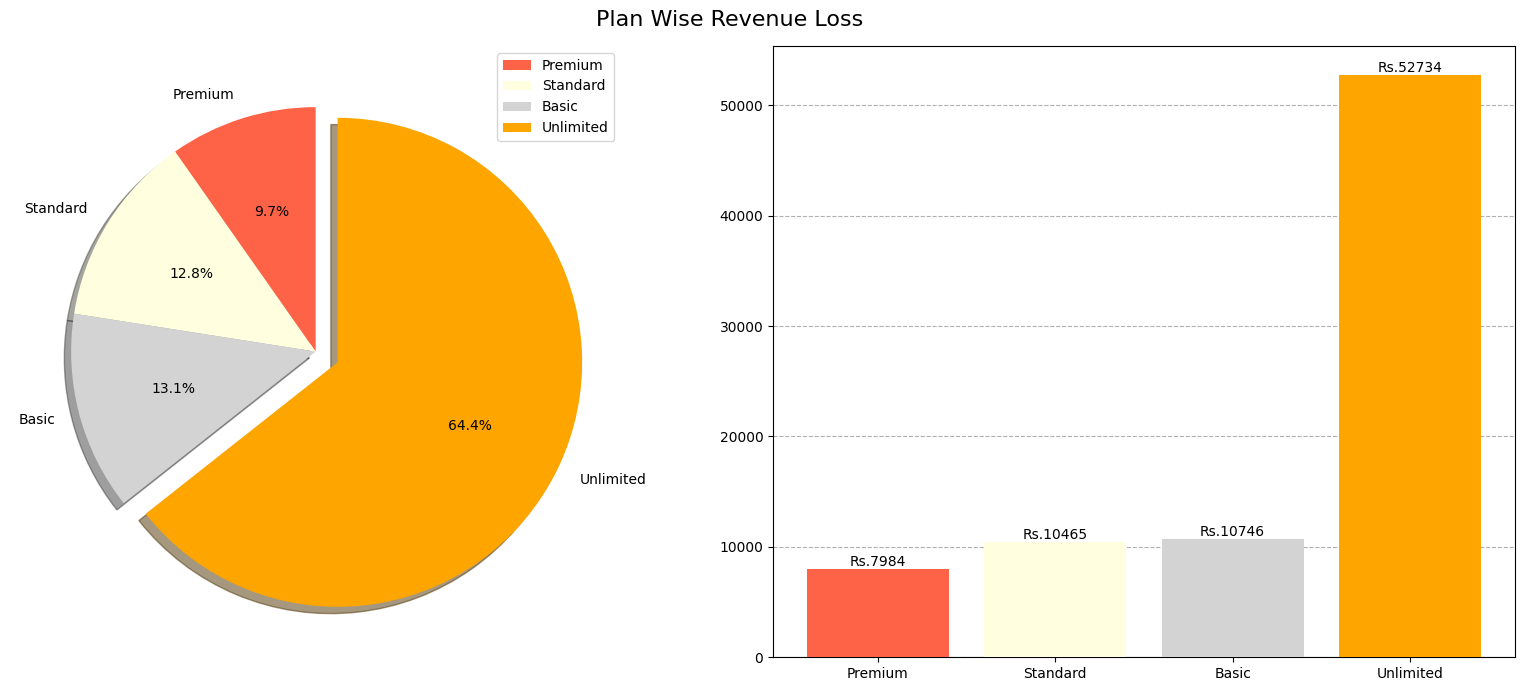

In [150]:
# Plan Wise Revenue Loss

plan_wise_revenue_loss = df[(df['Payment_Status']=='Paid') & (df['Status']=='Inactive')].groupby('Plan_Name').agg(
    Revenue = ('Total_Revenue','sum')
).sort_values('Revenue',ascending=True)

plt.figure(figsize=(16,7))
plt.subplot(1,2,1)
plt.pie(plan_wise_revenue_loss['Revenue'],labels=plan_wise_revenue_loss.index,colors=['tomato','lightyellow','lightgray','orange'],startangle=90,explode=[0,0,0,0.1],shadow=True,autopct='%1.1f%%')
#plt.title('Plan wise - Revenue Loss',pad=10)
plt.legend()

plt.subplot(1,2,2)
plt.bar(plan_wise_revenue_loss.index,plan_wise_revenue_loss['Revenue'],color=['tomato','lightyellow','lightgray','orange'],zorder=3)
for x,y in zip(plan_wise_revenue_loss.index,plan_wise_revenue_loss['Revenue']):
  plt.text(x,y,f'Rs.{y}',ha='center',va='bottom')

plt.grid(zorder=0,axis='y',linestyle='--')
plt.suptitle('Plan Wise Revenue Loss',fontsize=16)
plt.tight_layout(rect=[0,0,1,1])
plt.show()

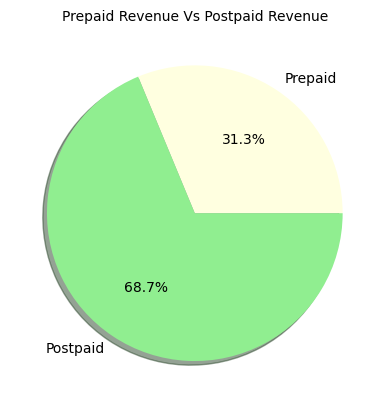

In [125]:
#Revenue by Plan Type

revenue_by_plan_type = df.groupby('Plan_Type').agg(
    Revenue = ('Total_Revenue','sum')
).sort_values('Revenue',ascending=True)

plt.pie(revenue_by_plan_type['Revenue'],labels=revenue_by_plan_type.index,autopct='%1.1f%%',shadow=True,colors=['lightyellow','lightgreen'])
plt.title('Prepaid Revenue Vs Postpaid Revenue',fontsize=10)
plt.show()

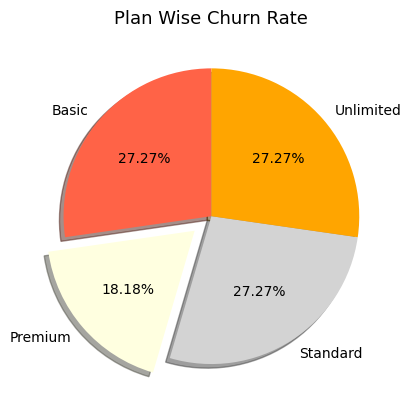

In [152]:
#Churn rate by plan

total_churned_cust_count = df[df['churn']==1].value_counts().sum()

plan_wise_churned_rate = df.groupby('Plan_Name').agg(
    churncount = ('churn','sum'),
)

plan_wise_churned_rate['Churnrate'] = (plan_wise_churned_rate['churncount'] / total_churned_cust_count)*100

plt.pie(plan_wise_churned_rate['Churnrate'],labels=plan_wise_churned_rate.index,autopct='%1.2f%%',shadow=True,startangle=90,colors=['tomato','lightyellow','lightgray','orange'],explode=[0,0.15,0,0])
plt.title('Plan Wise Churn Rate',fontsize=13) # fontweight='bold'
plt.show()

**Region Analysis**

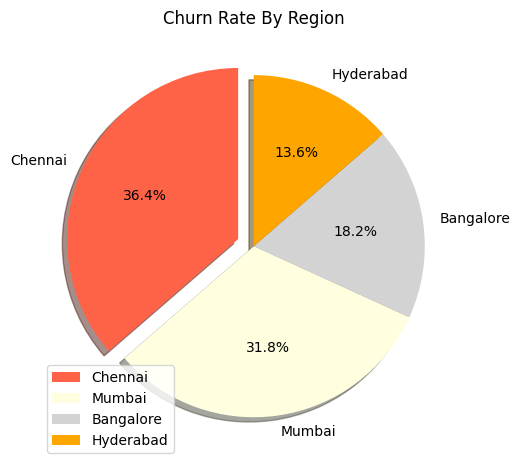

In [127]:
# Churn Rate by Region

churned_rate_by_customer = df.groupby('Region').agg(
    Churn_count = ('churn','sum')
).sort_values('Churn_count',ascending=False)

churned_rate_by_customer

plt.pie(churned_rate_by_customer['Churn_count'],labels=churned_rate_by_customer.index,colors=['tomato','lightyellow','lightgray','orange'],startangle=90,shadow=1,autopct='%1.1f%%',explode=[0.1,0,0,0])
plt.title('Churn Rate By Region')
plt.legend()
plt.tight_layout()
plt.show()

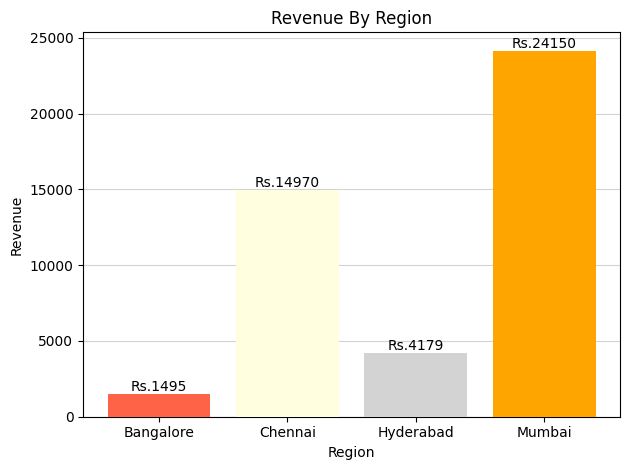

In [128]:
# Revenue By Region
region_revenue = df[(df['Payment_Status']=='Paid') & (df['Status']=='Active')].groupby('Region').agg(
    revenue = ('Total_Revenue','sum')
)

plt.bar(region_revenue.index,region_revenue['revenue'],color=['tomato','lightyellow','lightgray','orange'],zorder=3)
plt.title('Revenue By Region')
for x,y in zip(region_revenue.index,region_revenue['revenue']):
  plt.text(x,y,f'Rs.{y}',ha='center',va='bottom')
plt.xlabel('Region')
plt.ylabel('Revenue')
plt.grid(axis='y',color='lightgray',zorder=0)
plt.tight_layout()
plt.show()

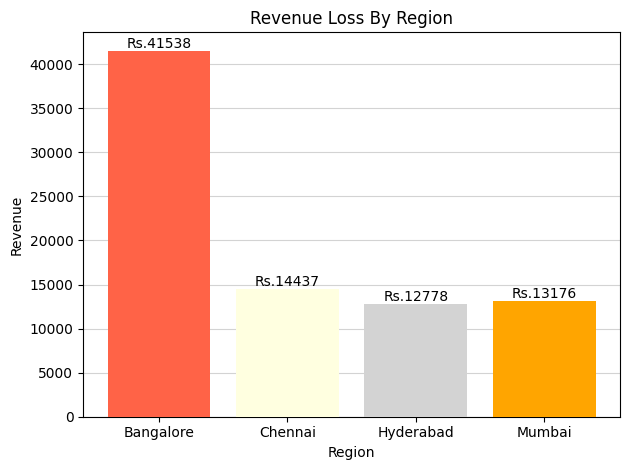

In [129]:
# Revenue Loss By Region
region_revenue_loss = df[(df['Payment_Status']=='Paid') & (df['Status']=='Inactive')].groupby('Region').agg(
    revenue = ('Total_Revenue','sum')
)

plt.bar(region_revenue_loss.index,region_revenue_loss['revenue'],color=['tomato','lightyellow','lightgray','orange'],zorder=3)
plt.title('Revenue Loss By Region')
for x,y in zip(region_revenue_loss.index,region_revenue_loss['revenue']):
  plt.text(x,y,f'Rs.{y}',ha='center',va='bottom')
plt.xlabel('Region')
plt.ylabel('Revenue')
plt.grid(axis='y',color='lightgray',zorder=0)
plt.tight_layout()
plt.show()

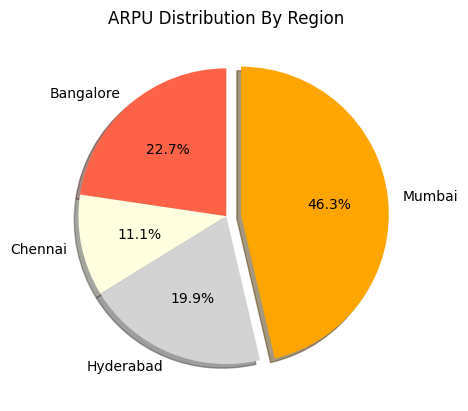

In [130]:
# ARPU Distribution by Region
arpu_by_region = df.groupby('Region').agg(
    arpu = ('ARPU','mean')
)

arpu_by_region['arpu'] *= 1e12

plt.pie(arpu_by_region['arpu'],labels=arpu_by_region.index,startangle=90,colors=['tomato','lightyellow','lightgray','orange'],shadow=True,explode=[0,0,0,0.1],autopct='%1.1f%%')
plt.title('ARPU Distribution By Region')
plt.show()

**High Value Customers**

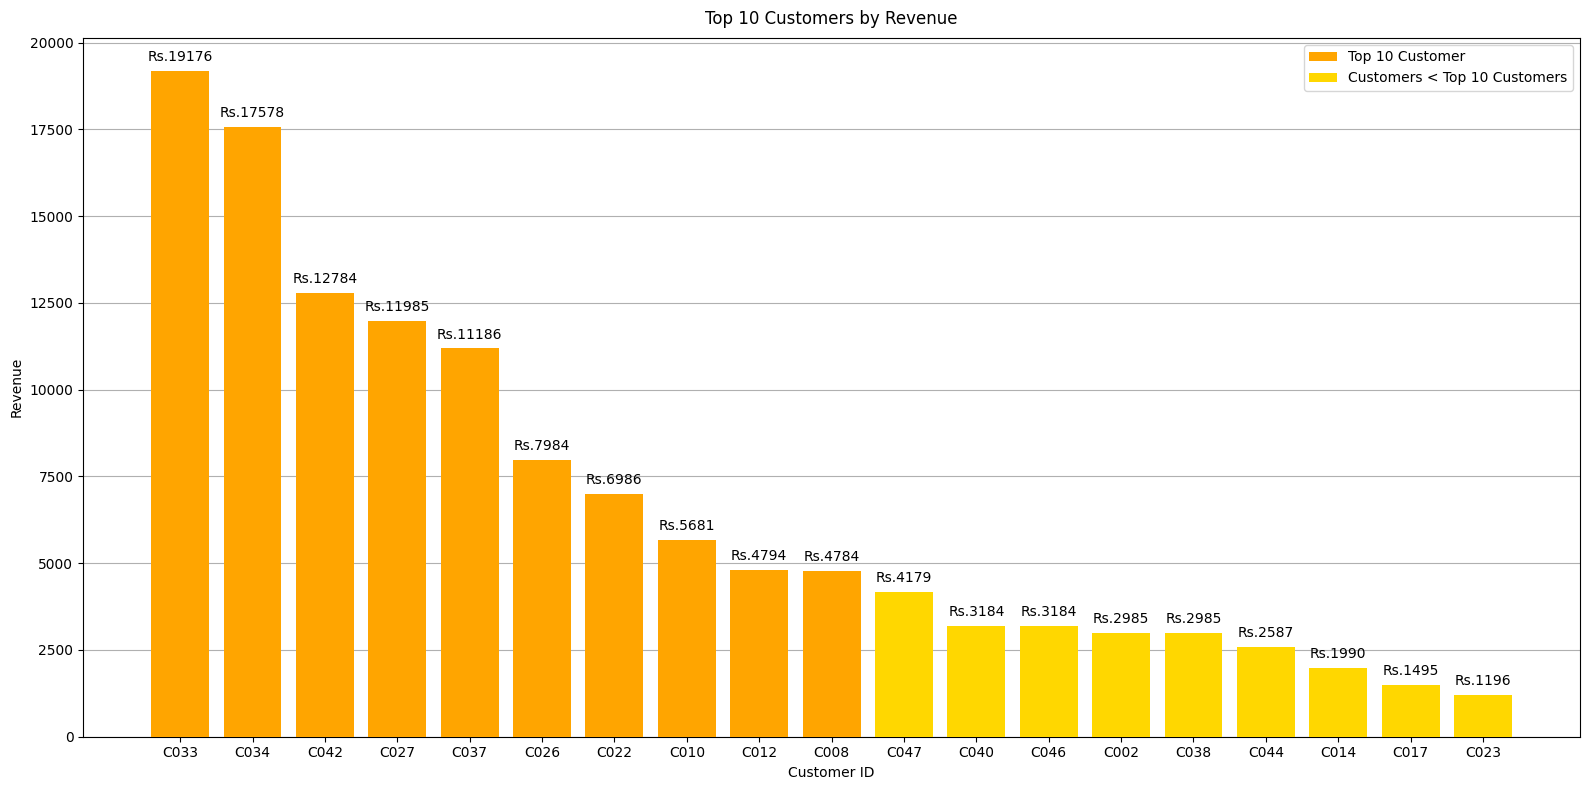

In [131]:
#Top 10 customers by revenue
from matplotlib.patches import Patch
customer_revenue = df[df['Payment_Status']=='Paid'].groupby('Customer_ID').agg(
    Revenue = ('Total_Revenue','sum'),
    churn = ('churn','sum')
)


top_10_customers = customer_revenue.sort_values('Revenue',ascending=False)

plt.figure(figsize=(16,8))
plt.bar(top_10_customers.index,top_10_customers['Revenue'],zorder=3,
        color = [
            'Orange' if i<10
            else 'gold'
            for i in range(len(top_10_customers))
        ]
        )

for x,y in zip(top_10_customers.index,top_10_customers['Revenue']):
  plt.text(x,y+200,f'Rs.{y}',ha='center',va='bottom')

legend_property = [
    Patch(facecolor='orange',label='Top 10 Customer'),
    Patch(facecolor='gold',label='Customers < Top 10 Customers')
]

plt.legend(handles=legend_property)

plt.title('Top 10 Customers by Revenue',pad=10)
plt.xlabel('Customer ID')
plt.ylabel('Revenue')
plt.grid(axis='y',zorder=0)
plt.tight_layout()
plt.show()

/tmp/ipykernel_880/962227371.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cust['Churn_Rate ?'] = cust['churn'].apply(


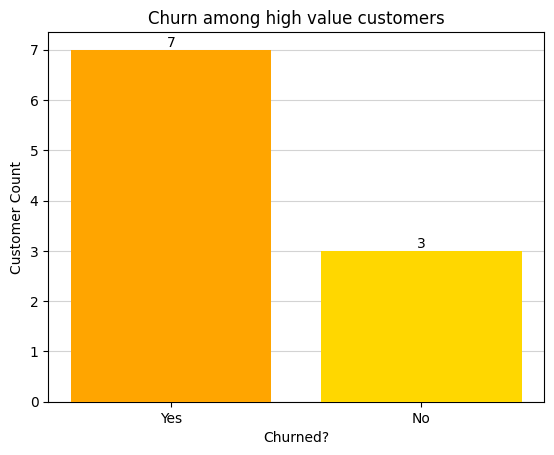

In [132]:
# Churn among high value customers
high_val_customers = customer_revenue['Revenue'].quantile(0.50)

cust=customer_revenue[customer_revenue['Revenue']>=high_val_customers]

cust['Churn_Rate ?'] = cust['churn'].apply(
    lambda x:'Yes' if x==1 else 'No'
)

churned=cust['Churn_Rate ?'].value_counts()

plt.bar(churned.index,churned,zorder=3,color=['Orange','gold'])

for x,y in zip(churned.index,churned):
  plt.text(x,y,y,ha='center',va='bottom')

plt.title('Churn among high value customers')
plt.xlabel('Churned?')
plt.ylabel('Customer Count')
plt.grid(axis='y',color='lightgray',zorder=0)
plt.show()


In [133]:
tenure_cust = df[['Customer_ID','churn']]
tenure_cust['tenure']=(pd.to_datetime('today')-pd.to_datetime(df['Join_Date'])).dt.days

tenure_cust['tenure'].describe()

/tmp/ipykernel_880/3176108863.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tenure_cust['tenure']=(pd.to_datetime('today')-pd.to_datetime(df['Join_Date'])).dt.days


,tenure
count,50.000000
mean,447.260000
std,243.234313
min,41.000000
25%,262.750000
50%,461.500000
75%,621.250000
max,888.000000


In [134]:
def tenure_cate(x):
  if x >= 618: #qunatile 0.75
    return 'above 618 days'
  elif x>= 444: # mean 444
    return f'444 days to 618 days'
  else:
    return f'below 444 days'

tenure_cust['tenure_category'] = tenure_cust['tenure'].apply(tenure_cate)

tenure_cust['Churned ?'] = tenure_cust['churn'].apply(
    lambda x:'Yes' if x==1 else 'No'
)

/tmp/ipykernel_880/1521480476.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tenure_cust['tenure_category'] = tenure_cust['tenure'].apply(tenure_cate)
/tmp/ipykernel_880/1521480476.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tenure_cust['Churned ?'] = tenure_cust['churn'].apply(


In [135]:
tenure_cust

,Customer_ID,churn,tenure,tenure_category,Churned ?
0,C001,1,544,444 days to 618 days,Yes
1,C002,1,288,below 444 days,Yes
2,C003,0,413,below 444 days,No
3,C004,0,540,444 days to 618 days,No
4,C005,0,583,444 days to 618 days,No
5,C006,1,135,below 444 days,Yes
6,C007,0,285,below 444 days,No
7,C008,1,718,above 618 days,Yes
8,C009,0,623,above 618 days,No
9,C010,1,624,above 618 days,Yes


In [136]:
churn_vs_tenure = pd.pivot_table(data=tenure_cust,index='tenure_category',columns='Churned ?',values='Customer_ID',aggfunc='count')
churn_vs_tenure

Churned ?,No,Yes
tenure_category,,
444 days to 618 days,9,4
above 618 days,6,8
below 444 days,13,10


In [137]:
churn_vs_tenure=churn_vs_tenure.div(churn_vs_tenure.sum(axis=1),axis=0)*100


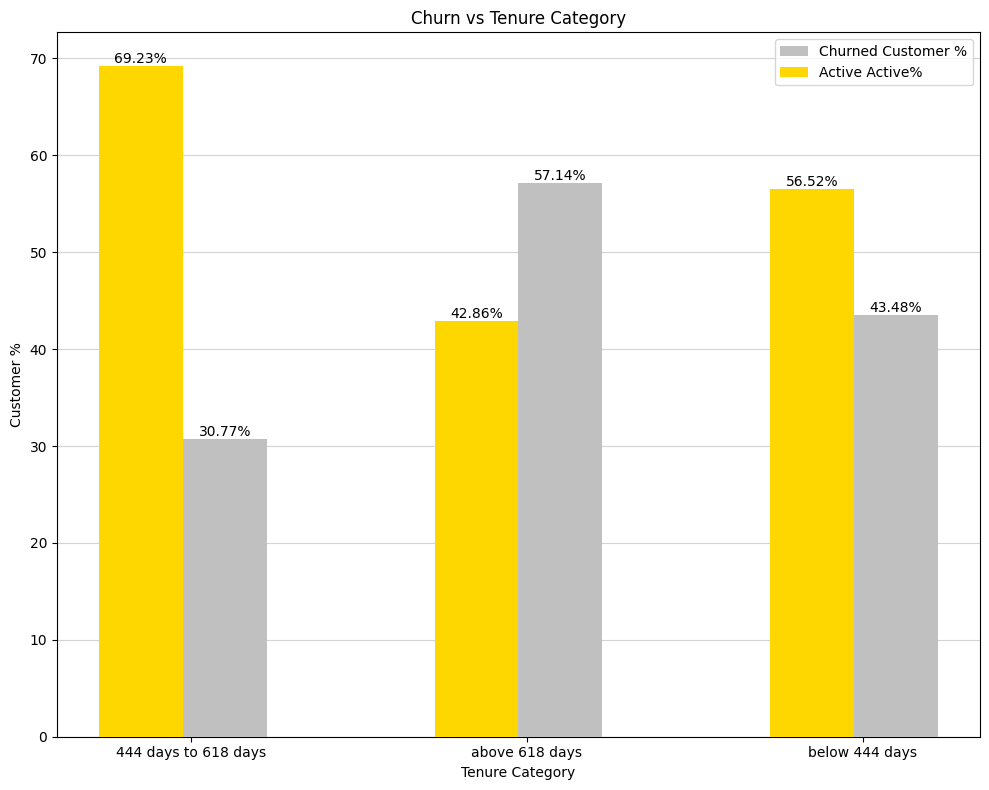

In [138]:
category = churn_vs_tenure.index

x = np.arange(len(category))
width=0.25

plt.figure(figsize=(10,8))
bar1 = plt.bar(x-width,churn_vs_tenure['No'],width,color='gold',zorder=3)
bar2 = plt.bar(x,churn_vs_tenure['Yes'],width,color='silver',zorder=3)

for bars in [bar1,bar2]:
  for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,height,f'{height:.2f}%',ha='center',va='bottom')

plt.title('Churn vs Tenure Category')
plt.xlabel('Tenure Category')
plt.ylabel('Customer %')
legend = [
    Patch(facecolor='silver',label='Churned Customer %'),
    Patch(facecolor='gold',label='Active Active%')
]


plt.legend(handles=legend)
plt.xticks(x-0.1,category)
plt.grid(zorder=0,color='lightgray',axis='y')
plt.tight_layout()

plt.show()

In [139]:
# Usage impact on churn
df['tenure']=(pd.to_datetime('today')-pd.to_datetime(df['Join_Date'])).dt.days

df['tenure_category'] = df['tenure'].apply(tenure_cate)

df

,Customer_ID,Age,Region,Join_Date,Status,Monthly_Data_Usage_GB,Call_Minutes,SMS_Count,Plan_ID,Plan_Name,Plan_Type,Price,Total_Revenue,Payment_Status,churn,ARPU,age_category,tenure,tenure_category
0,C001,25,Chennai,2024-12-10,Inactive,47.30,569,52,P004,Unlimited,Postpaid,799,15181,Pending,1,27.906250,Below 30,544,444 days to 618 days
1,C002,48,Chennai,2025-08-23,Inactive,45.43,1472,159,P001,Basic,Prepaid,199,2985,Paid,1,10.364583,Above 40,288,below 444 days
2,C003,43,Bangalore,2025-04-20,Active,26.47,1494,146,P001,Basic,Prepaid,199,3781,Pending,0,9.154964,Above 40,413,below 444 days
3,C004,25,Bangalore,2024-12-14,Active,39.54,1035,10,P004,Unlimited,Postpaid,799,8789,Pending,0,16.275926,Below 30,540,444 days to 618 days
4,C005,20,Mumbai,2024-11-01,Active,18.75,1446,204,P001,Basic,Prepaid,199,3980,Pending,0,6.826758,Below 30,583,444 days to 618 days
5,C006,55,Mumbai,2026-01-23,Inactive,41.74,937,214,P002,Standard,Prepaid,299,6578,Pending,1,48.725926,Above 40,135,below 444 days
6,C007,26,Hyderabad,2025-08-26,Active,32.19,1495,96,P001,Basic,Prepaid,199,2786,Pending,0,9.775439,Below 30,285,below 444 days
7,C008,29,Bangalore,2024-06-19,Inactive,24.22,927,275,P002,Standard,Prepaid,299,4784,Paid,1,6.662953,Below 30,718,above 618 days
8,C009,50,Bangalore,2024-09-22,Active,48.50,1381,166,P004,Unlimited,Postpaid,799,19176,Pending,0,30.780096,Above 40,623,above 618 days
9,C010,51,Chennai,2024-09-21,Inactive,18.01,1481,35,P002,Standard,Prepaid,299,5681,Paid,1,9.104167,Above 40,624,above 618 days


In [140]:
usage_impact_churn = df[['Customer_ID','Monthly_Data_Usage_GB','Call_Minutes','SMS_Count','churn','tenure_category']]
usage_impact_churn['Churned ?'] = usage_impact_churn['churn'].apply(
    lambda x:'Yes' if x==1 else 'No'
)

usage_impact_churn

/tmp/ipykernel_880/228271021.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  usage_impact_churn['Churned ?'] = usage_impact_churn['churn'].apply(


,Customer_ID,Monthly_Data_Usage_GB,Call_Minutes,SMS_Count,churn,tenure_category,Churned ?
0,C001,47.30,569,52,1,444 days to 618 days,Yes
1,C002,45.43,1472,159,1,below 444 days,Yes
2,C003,26.47,1494,146,0,below 444 days,No
3,C004,39.54,1035,10,0,444 days to 618 days,No
4,C005,18.75,1446,204,0,444 days to 618 days,No
5,C006,41.74,937,214,1,below 444 days,Yes
6,C007,32.19,1495,96,0,below 444 days,No
7,C008,24.22,927,275,1,above 618 days,Yes
8,C009,48.50,1381,166,0,above 618 days,No
9,C010,18.01,1481,35,1,above 618 days,Yes


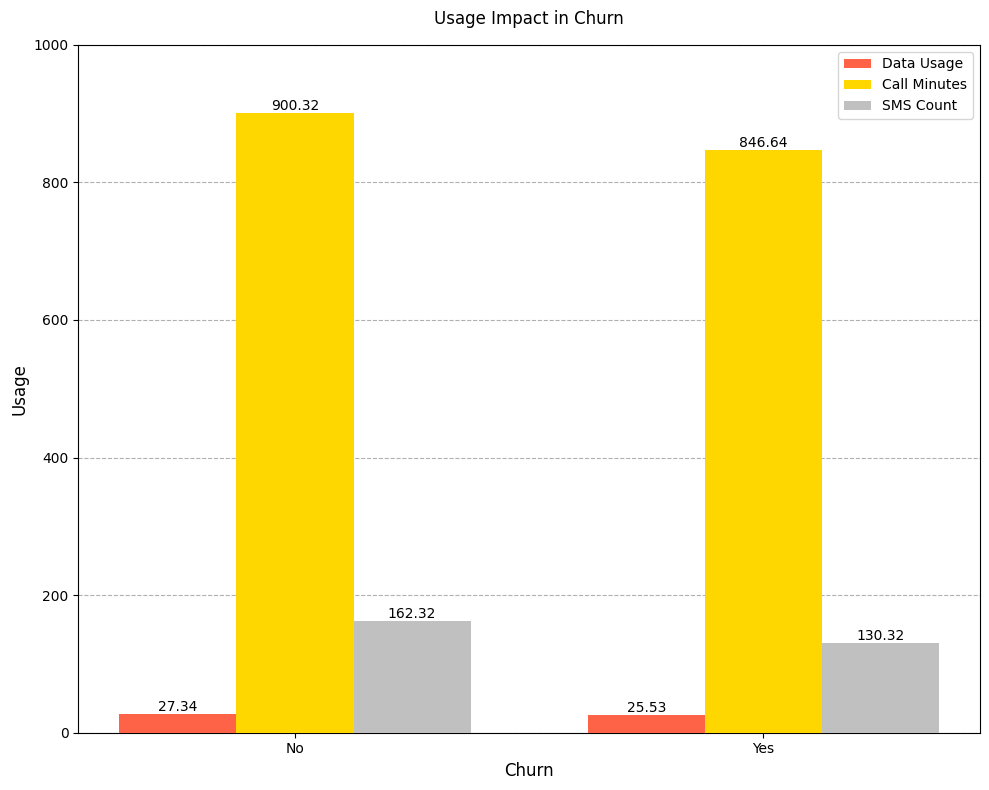

In [141]:
usage_impact_on_churn = pd.pivot_table(data=usage_impact_churn,index='Churned ?',values=['Monthly_Data_Usage_GB','Call_Minutes','SMS_Count'],aggfunc='mean')

churned = usage_impact_on_churn.index

x=np.arange(len(churned))
width = 0.25
plt.figure(figsize=(10,8))
bar1 = plt.bar(x-width,usage_impact_on_churn['Monthly_Data_Usage_GB'],width=width,label='Data Usage',zorder=3,color='tomato')
bar2 = plt.bar(x,usage_impact_on_churn['Call_Minutes'],width=width,label='Call Minutes',zorder=3,color='gold')
bar3 = plt.bar(x+width,usage_impact_on_churn['SMS_Count'],width=width,label='SMS Count',zorder=3,color='silver')


for bars in [bar1,bar2,bar3]:
  for bar in bars:
    height = bar.get_height()
    width = bar.get_width()
    x_axis = bar.get_x()
    plt.text(x_axis+width/2,height,f'{height:.2f}',ha='center',va='bottom',fontsize=10)

plt.title('Usage Impact in Churn',fontsize=12,pad=15)
plt.xlabel('Churn',fontsize=12)
plt.ylabel('Usage',fontsize=12)
plt.ylim(0,1000)
plt.xticks(x,churned)
plt.grid(axis='y',zorder=0,linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

**Price impact on churn**

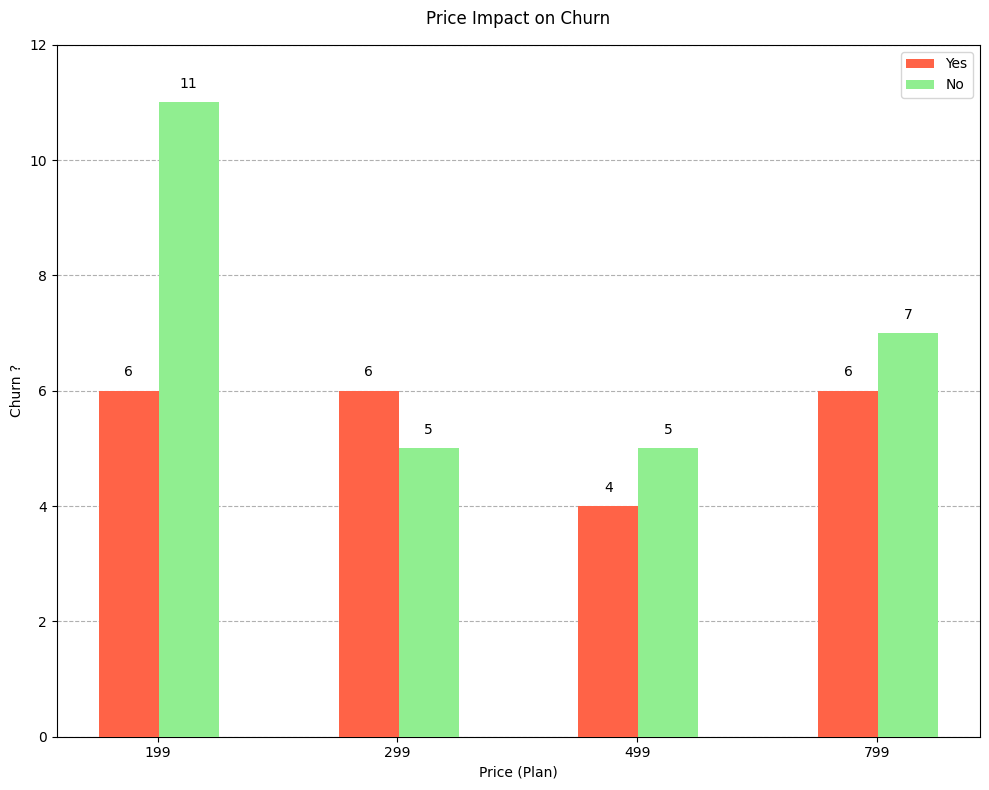

In [142]:
price_impact_on_churn = df.pivot_table(index='Price',columns='churn',values='Customer_ID',aggfunc='count')

price_impact_on_churn.rename(columns={0:'No',1:'Yes'},inplace=True)

price_impact_on_churn

plt.figure(figsize=(10,8))
Price = price_impact_on_churn.index
x= np.arange(len(Price))
bar_width = 0.25
Yes = plt.bar(x-bar_width,price_impact_on_churn['Yes'],width=bar_width,label='Yes',color='tomato',zorder=3)
No = plt.bar(x,price_impact_on_churn['No'],width=bar_width,label='No',color='lightgreen',zorder=3)

for bars in [Yes,No]:
  for bar in bars:
    height = bar.get_height()
    x_axis = bar.get_x()
    bar_width = bar.get_width()
    plt.text(x_axis+bar_width/2,height+0.2,height,ha='center',va='bottom')


plt.title('Price Impact on Churn',fontsize=12,pad=15)
plt.xlabel('Price (Plan)',fontsize=10)
plt.ylabel('Churn ?',fontsize=10)
plt.ylim(0,12)
plt.xticks(x-0.13,Price)
plt.grid(axis='y',linestyle='--',zorder=0)
plt.legend()
plt.tight_layout()
plt.show()

In [143]:
# Plan + region churn combination
plan_region_churn_comb = df.pivot_table(index='churn',columns=['Region','Price'],values='Customer_ID',aggfunc='count')
plan_region_churn_comb.rename(index={0:'No',1:'Yes'},inplace=True)

plan_region_churn_comb.fillna(0,inplace=True)

plan_region_churn_comb_count = plan_region_churn_comb

plan_region_churn_comb_count

Region Bangalore                Chennai                Hyderabad            \
Price        199  299  499  799     199  299  499  799       199  299  499   
churn                                                                        
No           3.0  3.0  1.0  2.0     2.0  0.0  1.0  1.0       3.0  1.0  0.0   
Yes          0.0  2.0  0.0  2.0     3.0  2.0  1.0  2.0       1.0  0.0  1.0   

Region      Mumbai                 
Price   799    199  299  499  799  
churn                              
No      2.0    3.0  1.0  3.0  2.0  
Yes     1.0    2.0  2.0  2.0  1.0

In [144]:
chur_percent = plan_region_churn_comb.div(plan_region_churn_comb.sum(axis=0),axis=1)*100

chur_percent

Region Bangalore                    Chennai                         Hyderabad  \
Price        199   299    499   799     199    299   499        799       199   
churn                                                                           
No         100.0  60.0  100.0  50.0    40.0    0.0  50.0  33.333333      75.0   
Yes          0.0  40.0    0.0  50.0    60.0  100.0  50.0  66.666667      25.0   

Region                          Mumbai                              
Price     299    499        799    199        299   499        799  
churn                                                               
No      100.0    0.0  66.666667   60.0  33.333333  60.0  66.666667  
Yes       0.0  100.0  33.333333   40.0  66.666667  40.0  33.333333

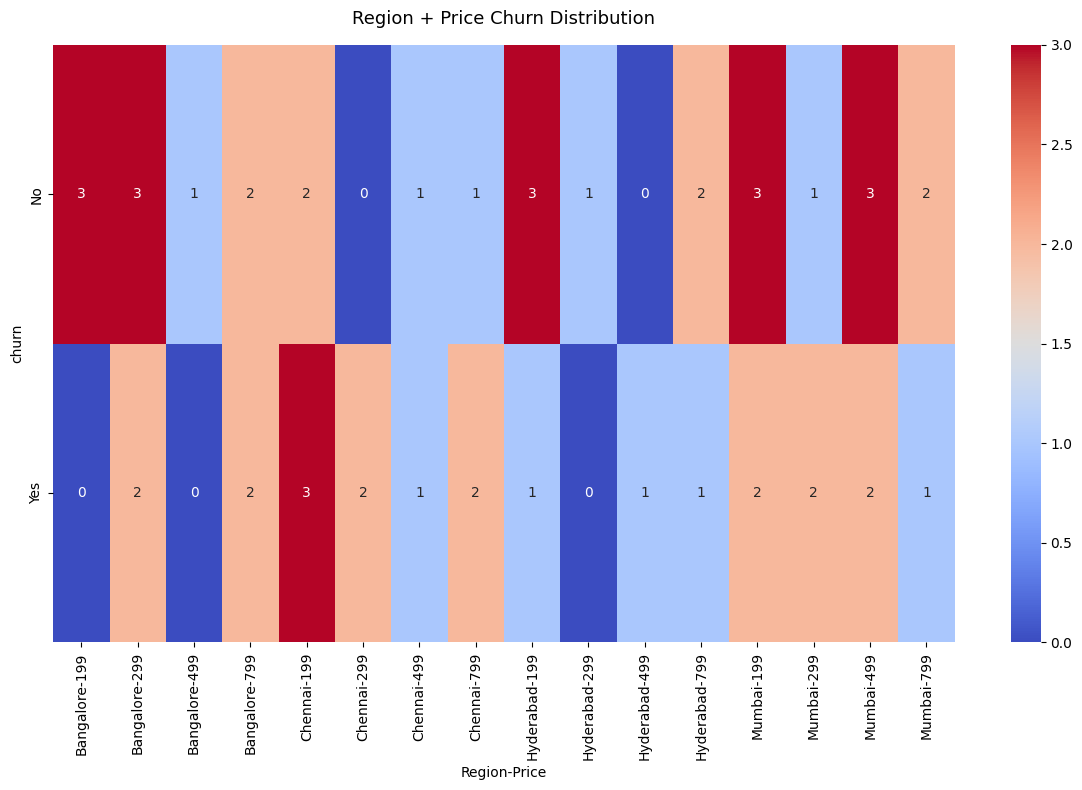

In [145]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(plan_region_churn_comb,annot=True,fmt='.0f',cmap='coolwarm')
plt.title('Region + Price Churn Distribution',fontsize=13,pad=15)
plt.tight_layout()
plt.show()